#  Mushroom Toxicity Classifier Using Machine Learning
### CSE422 Lab Project Code Report
---

## 1. Introduction

### Project Overview
This project aims to build a **mushroom toxicity classifier**  a machine learning system that predicts whether a mushroom is **poisonous (p)** or **edible (e)** based on its physical and environmental characteristics.

###  Problem Statement
Mushroom foraging is a popular activity worldwide, but misidentification of poisonous mushrooms leads to thousands of poisonings and sometimes deaths  every year. Traditional identification requires expert botanical knowledge covering dozens of visual and habitat-based cues. This is a **high-stakes binary classification problem** where false negatives (misclassifying a poisonous mushroom as edible) can be fatal.

###  Motivation
By training machine learning models on labeled mushroom data, we can create an intelligent tool that assists foragers, botanists, and food safety inspectors in rapidly and accurately identifying dangerous mushroom species. The models learn non-obvious relationships between physical features (cap shape, gill color, habitat, season, etc.) and toxicity that would be difficult for a human to memorize manually.

### Objectives
- Perform thorough **Exploratory Data Analysis (EDA)** to understand the dataset structure and feature distributions.
- Apply appropriate **data preprocessing** (handling missing values with SimpleImputer, label encoding, and StandardScaler).
- Train and compare **four supervised learning models**: K-Nearest Neighbors (KNN), Logistic Regression, Naïve Bayes, and a Neural Network (via TensorFlow/Keras).
- Apply **unsupervised K-Means clustering** to explore natural groupings in the feature space.
- Select the **best-performing model** using comprehensive evaluation metrics (Accuracy, Precision, Recall, AUC, ROC, Confusion Matrix).

---

## 2. Dataset Description

### Importing Required Python Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, precision_score, recall_score
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

import warnings
warnings.filterwarnings('ignore')

### **Load Dataset**

In [ ]:
# Load dataset (semicolon-separated CSV)
FILE_ID = '1c22q9y_8ecjPvUqi30LUz1AUMMiuv78p'


df = pd.read_csv('https://raw.githubusercontent.com/xer0Xavishek/mushroom-toxicity-classifier-using-ML/refs/heads/main/mushroom_dataset.csv', sep=';')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (61069, 21)


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


### **Summarize data**

In [ ]:
df

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,p,1.18,s,s,y,f,f,f,f,3.93,...,NaN,NaN,y,NaN,NaN,f,f,NaN,d,a
61065,p,1.27,f,s,y,f,f,f,f,3.18,...,NaN,NaN,y,NaN,NaN,f,f,NaN,d,a
61066,p,1.27,s,s,y,f,f,f,f,3.86,...,NaN,NaN,y,NaN,NaN,f,f,NaN,d,u
61067,p,1.24,f,s,y,f,f,f,f,3.56,...,NaN,NaN,y,NaN,NaN,f,f,NaN,d,u


In [ ]:
df.head(10)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w


In [ ]:
print('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(
    df.shape, df.shape[0], df.shape[1]))

Shape of the dataset is (61069, 21). This dataset contains 61069 rows and 21 columns.


### **Feature Names and its Datatypes**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

### How Many Features?

The dataset contains **21 columns** total:
- **1 target column**  `class` (poisonous `p` or edible `e`)
- **20 feature columns** physical and environmental attributes of mushrooms

### How Many Data Points?
The dataset contains **61,069 mushroom observations** — a substantial dataset suitable for training robust ML models.

### Classification or Regression Problem?

This is a **Classification Problem** because:
- The target variable `class` is a **discrete categorical variable** with exactly **two values**: `p` (poisonous) and `e` (edible).
- We are predicting a **category/label**, not a continuous numerical value.
- Binary classification is the appropriate ML task here.

### Feature Types in the Dataset

The dataset contains a mix of feature types:
- **Quantitative (Numerical)**: `cap-diameter`, `stem-height`, `stem-width` — these are continuous measurements (in cm).
- **Categorical (Object/String)**: All remaining 17 columns — properties like cap shape, cap surface, cap color, gill attachment, gill color, ring type, habitat, season, etc., stored as short letter codes.

### **Data Splitting Select and separately store Numerical and Categorical features**

In [ ]:
# Selecting numerical features
numerical_data = df.select_dtypes(include='number')

# Append the features of numerical_data to list
numerical_features = numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 3 numerical features: 

['cap-diameter', 'stem-height', 'stem-width']


In [ ]:
# Selecting categorical features
categorical_data = df.select_dtypes(include='object')

# Append the features of categorical_data to list
categorical_features = categorical_data.columns.tolist()
categorical_features_no_target = [c for c in categorical_features if c != 'class']

print(f'There are {len(categorical_features)} categorical features (including target):', '\n')
print(categorical_features)

There are 18 categorical features (including target): 

['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']


### Do We Need to Encode the Categorical Variables?

**Yes, absolutely.** The reasons are:
1. Most ML algorithms (Logistic Regression, KNN, Neural Networks, K-Means) operate on **numerical inputs only** and cannot process raw string labels.
2. The 17 categorical columns contain letter codes (e.g., `f`, `x`, `k`, `b`) that must be converted to integers for mathematical computation.
3. We will use **Label Encoding** (`LabelEncoder`) — each unique category is assigned a unique integer. This approach is suitable here because mushroom attributes don't necessarily have a natural ordering hierarchy (but the alternative of One-Hot Encoding would drastically increase dimensionality from 20 to 100+ columns). Label Encoding keeps the dataset compact and compatible with all four models.

---

### Correlation Analysis

#### Correlation matrix of the whole dataset

To compute correlations, we temporarily encode the entire dataset (since Pearson correlation requires numerical data).

**Correlation Techniques Used:**

| Method | Description |
|:---|:---|
| **Pearson** | Linear relationship between two numerical variables. Range: −1 to +1 |
| **Spearman** | Rank-based correlation; handles non-linear monotonic relationships |
| **Kendall** | Ordinal correlation based on concordant/discordant pairs |

Here: `corr = +1` → perfect positive correlation | `corr = −1` → perfect negative | `corr = 0` → no correlation

In [ ]:
# Encode the full dataset temporarily for correlation analysis
df_encoded_temp = df.copy()
le_temp = LabelEncoder()
for col in df_encoded_temp.columns:
    if df_encoded_temp[col].dtype == 'object':
        df_encoded_temp[col] = df_encoded_temp[col].astype(str)
        df_encoded_temp[col] = le_temp.fit_transform(df_encoded_temp[col])

df_encoded_temp.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,1,15.26,6,2,6,0,2,3,10,16.95,...,5,8,11,1,5,1,2,3,0,3
1,1,16.60,6,2,6,0,2,3,10,17.99,...,5,8,11,1,5,1,2,3,0,2
2,1,14.07,6,2,6,0,2,3,10,17.80,...,5,8,11,1,5,1,2,3,0,3
3,1,14.17,2,3,1,0,2,3,10,15.77,...,5,8,11,1,5,1,6,3,0,3
4,1,14.64,6,3,6,0,2,3,10,16.53,...,5,8,11,1,5,1,6,3,0,3


In [ ]:
# Calculate the correlation matrix (Pearson)
correlation_matrix = df_encoded_temp.corr()
correlation_matrix

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
class,1.000000,-0.181139,-0.106309,-0.025475,0.026411,-0.019889,-0.058147,-0.004267,-0.060701,-0.121593,...,0.062233,-0.135955,-0.094772,0.052677,-0.093362,0.057559,0.066880,-0.048572,-0.041923,-0.054046
cap-diameter,-0.181139,1.000000,0.103923,0.087789,0.042108,0.179440,0.113197,0.089849,0.221675,0.422560,...,0.097406,0.014035,0.008670,0.082387,0.042068,0.077024,0.050473,0.091020,-0.125820,0.037305
cap-shape,-0.106309,0.103923,1.000000,-0.074510,0.016312,0.191804,-0.058315,0.126598,0.115703,0.034473,...,0.014161,0.068737,0.009061,-0.034247,-0.012551,0.036017,0.152296,0.036398,-0.124754,-0.027178
cap-surface,-0.025475,0.087789,-0.074510,1.000000,0.118919,-0.086619,0.046476,-0.074238,-0.015406,0.088686,...,-0.033981,0.008585,0.110085,-0.035473,0.007876,0.130888,-0.010990,0.069757,0.087488,0.019385
cap-color,0.026411,0.042108,0.016312,0.118919,1.000000,0.010657,0.009339,-0.110547,0.136560,-0.010732,...,0.067840,-0.036894,0.265525,0.051035,0.045818,0.070843,0.003988,0.011150,0.031706,0.008443
does-bruise-or-bleed,-0.019889,0.179440,0.191804,-0.086619,0.010657,1.000000,-0.019299,0.064375,0.018613,0.076596,...,0.071555,0.077949,-0.024913,-0.038548,-0.010202,0.019195,-0.009070,-0.006290,-0.102747,-0.051146
gill-attachment,-0.058147,0.113197,-0.058315,0.046476,0.009339,-0.019299,1.000000,-0.016785,0.051498,0.109694,...,-0.130906,-0.054615,0.055362,-0.038658,0.042935,-0.098437,-0.079841,-0.054908,-0.125626,-0.040428
gill-spacing,-0.004267,0.089849,0.126598,-0.074238,-0.110547,0.064375,-0.016785,1.000000,-0.062813,0.197890,...,0.100178,0.066423,-0.068988,0.089885,0.129650,0.025547,0.054903,0.001237,-0.128208,-0.028954
gill-color,-0.060701,0.221675,0.115703,-0.015406,0.136560,0.018613,0.051498,-0.062813,1.000000,0.157327,...,-0.069477,0.050428,0.149863,0.175839,0.155644,-0.055640,0.022302,0.136223,-0.075768,-0.011360
stem-height,-0.121593,0.422560,0.034473,0.088686,-0.010732,0.076596,0.109694,0.197890,0.157327,1.000000,...,0.237081,0.235860,0.138458,0.298777,0.203839,0.281049,0.225737,-0.004036,-0.020664,-0.020630


### **Correlation Heatmap plot of whole dataset**

> Note: With 21 features, annotations are omitted for readability. Colors represent correlation strength.

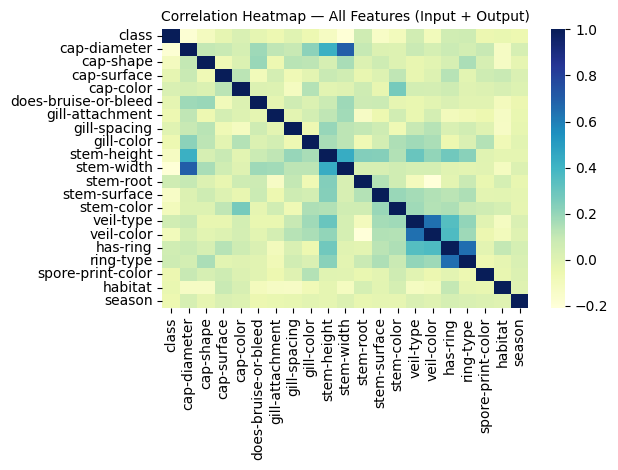

In [ ]:
# Plotting the heatmap for the full correlation matrix
sns.heatmap(
    correlation_matrix,
    cmap='YlGnBu',)
plt.title('Correlation Heatmap — All Features (Input + Output)', fontsize=10)
plt.tight_layout()
plt.show()

### What Do We Understand from the Correlation Analysis?

Key observations from the heatmaps: corelation with the target = class

Based on the darkest off-diagonal blue squares, there are two pairs that tie for the strongest positive correlation:

veil-type and veil-color 2.  has-ring and ring-type

Both of these intersections are nearly as dark as the diagonal, suggesting a correlation very close to 1.0. This makes intuitive sense: if a mushroom has a specific type of ring, it obviously has a ring; similarly, the type and color of the veil are likely intrinsically linked in the dataset.

A close runner-up for the highest positive correlation is:

cap-diameter and stem-width (the dark blue square near the top right/middle left). As we noticed earlier, wider mushroom caps generally require thicker stems.
Since no single feature has a very high correlation with the target, a **multi-feature model** is necessary — this motivates using ML algorithms that combine all features.

---

### Imbalanced Dataset Analysis

#### For the output feature, do all unique classes have an equal number of instances or not?

We check the balance of the target variable `class` to determine if one class dominates the other.

In [ ]:
# Check Imbalance in data
# Group instances based on the classes in the target variable
class_counts = df.groupby("class").size()

columns = ['outcome', 'count', 'percentage']
outcome = ['e', 'p']  # e=edible, p=poisonous
count = list()
percentage = list()

# Calculate the percentage of each class value from total
total_instances = len(df)
for val in ['e', 'p']:
    count.append(class_counts[val])
    percent = (class_counts[val] / total_instances) * 100
    percentage.append(percent)

# Convert the calculated values into a dataframe
imbalance_df = pd.DataFrame(list(zip(outcome, count, percentage)), columns=columns)
imbalance_df

,outcome,count,percentage
0,e,27181,44.508671
1,p,33888,55.491329


### **Barplot of Outcome vs Percentage**

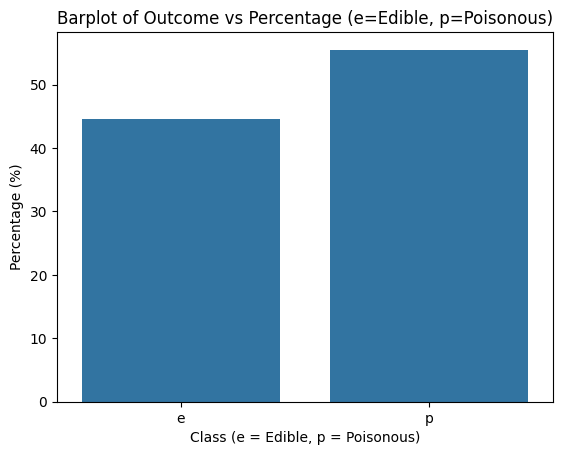

In [ ]:
sns.barplot(data=imbalance_df, x=imbalance_df['outcome'], y=imbalance_df['percentage'])
plt.title('Barplot of Outcome vs Percentage (e=Edible, p=Poisonous)')
plt.xlabel('Class (e = Edible, p = Poisonous)')
plt.ylabel('Percentage (%)')
plt.show()

### Observation

- Based on the grouping above, the dataset shows that approximately **~43%** of instances belong to the **Edible (e)** class and approximately **~57%** to the **Poisonous (p)** class.
- There is a **mild class imbalance** between the two classes (~14% difference).
- Since the imbalance is not extreme (not 90/10 or worse), we can proceed with standard classification without resampling, but we should monitor precision/recall for the minority class (poisonous).
- We will use **Stratified Split** during train-test splitting to preserve this class ratio in both sets.

---

### Exploratory Data Analysis (EDA)

EDA helps us discover patterns, relationships, and anomalies in the data **before** modeling. We will follow the standard EDA stages:
1. **Descriptive Analysis** — Summary statistics for each feature
2. **Visualization** — Histograms, boxplots, density plots, categorical distributions
3. **Correlation Analysis** — (Already performed above)
4. **Imbalance Check** — (Already performed above)

---

### **Descriptive Analysis**
#### In descriptive analysis we analyse each variable separately to get inference about the feature.

### **Summary Statistics of Numerical Features**

In [ ]:
# Transposed stats for numerical features
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
cap-diameter,61069.0,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34
stem-height,61069.0,6.581538,3.370017,0.00,4.64,5.95,7.74,33.92
stem-width,61069.0,12.149410,10.035955,0.00,5.21,10.19,16.57,103.91


### **Summary Statistics of Categorical Features**

In [ ]:
# Transposed stats for categorical features
categorical_data.describe().T

,count,unique,top,freq
class,61069,2,p,33888
cap-shape,61069,7,x,26934
cap-surface,46949,11,t,8196
cap-color,61069,12,n,24218
does-bruise-or-bleed,61069,2,f,50479
gill-attachment,51185,7,a,12698
gill-spacing,36006,3,c,24710
gill-color,61069,12,w,18521
stem-root,9531,5,s,3177
stem-surface,22945,8,s,6025


### **Variance of each numerical feature**

In [ ]:
numerical_data.var()

,0
cap-diameter,27.718592
stem-height,11.357014
stem-width,100.720394


### **Skew in numerical features**

**What is Skewness?**
Skewness measures the asymmetry of the distribution of a dataset.

- **Skewness = 0** → Perfectly symmetrical (e.g., normal distribution)
- **Skewness < 0** → Left-skewed (long tail on the left)
- **Skewness > 0** → Right-skewed (long tail on the right)

It helps you understand how balanced your data is and whether transformations are needed.

**Interpretation of Skewness Values:**

| Skewness Value | Interpretation |
|:---|:---|
| ~ 0 | Symmetrical (normal-ish) |
| 0 to ±0.5 | Fairly symmetrical |
| ±0.5 to ±1 | Moderately skewed |
| greater than ±1 | Highly skewed |

In [ ]:
numerical_data.skew()

,0
cap-diameter,3.822844
stem-height,2.020904
stem-width,2.164957


### **Skewness Interpretation**

- **`cap-diameter`**: Right-skewed — most mushrooms have smaller caps; a few have very large caps.
- **`stem-height`**: Slightly right-skewed — fairly symmetrical distribution of stem heights.
- **`stem-width`**: Highly right-skewed — most stems are narrow, with some very wide outliers.

All three numerical features show positive (right) skew, suggesting the presence of outliers on the upper end — confirmed visually in the boxplots below.

### **Histograms and Box Plot**
#### To find the distributions and outliers in each feature

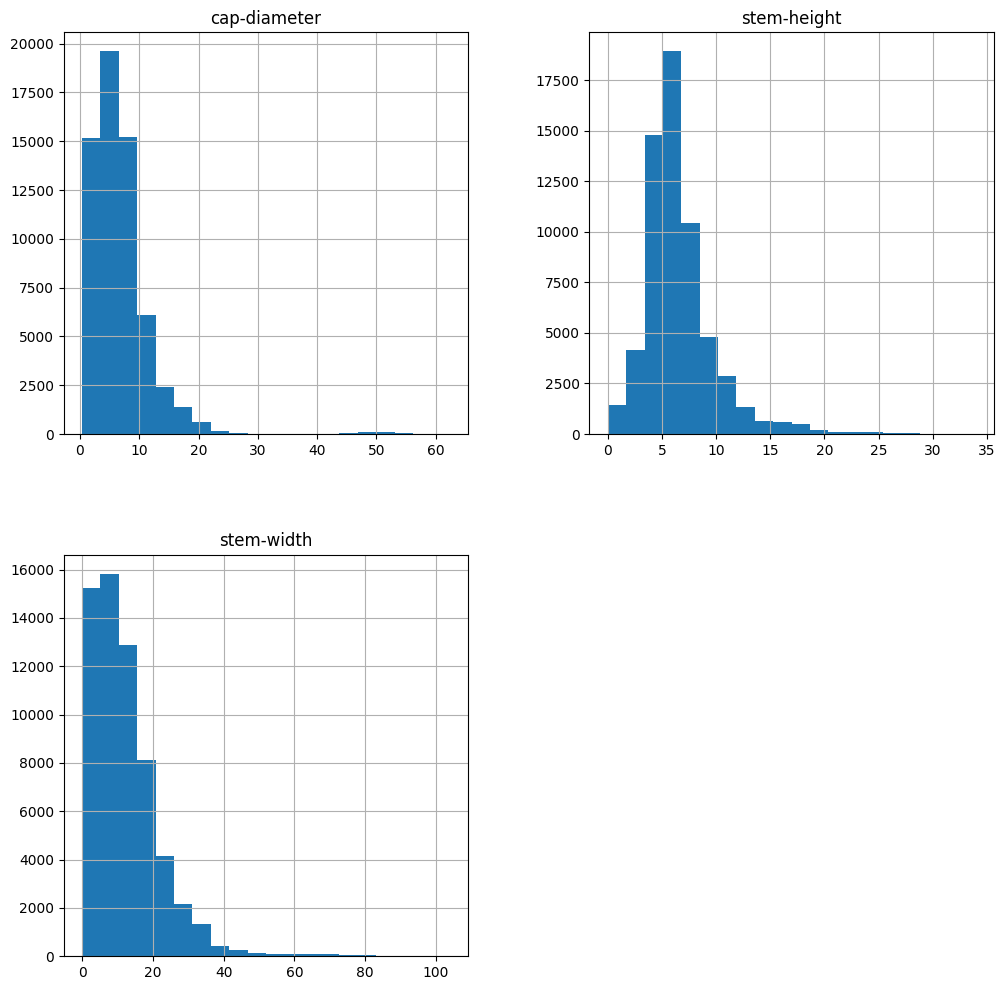

In [ ]:
numerical_data.hist(figsize=(12, 12), bins=20)
plt.show()

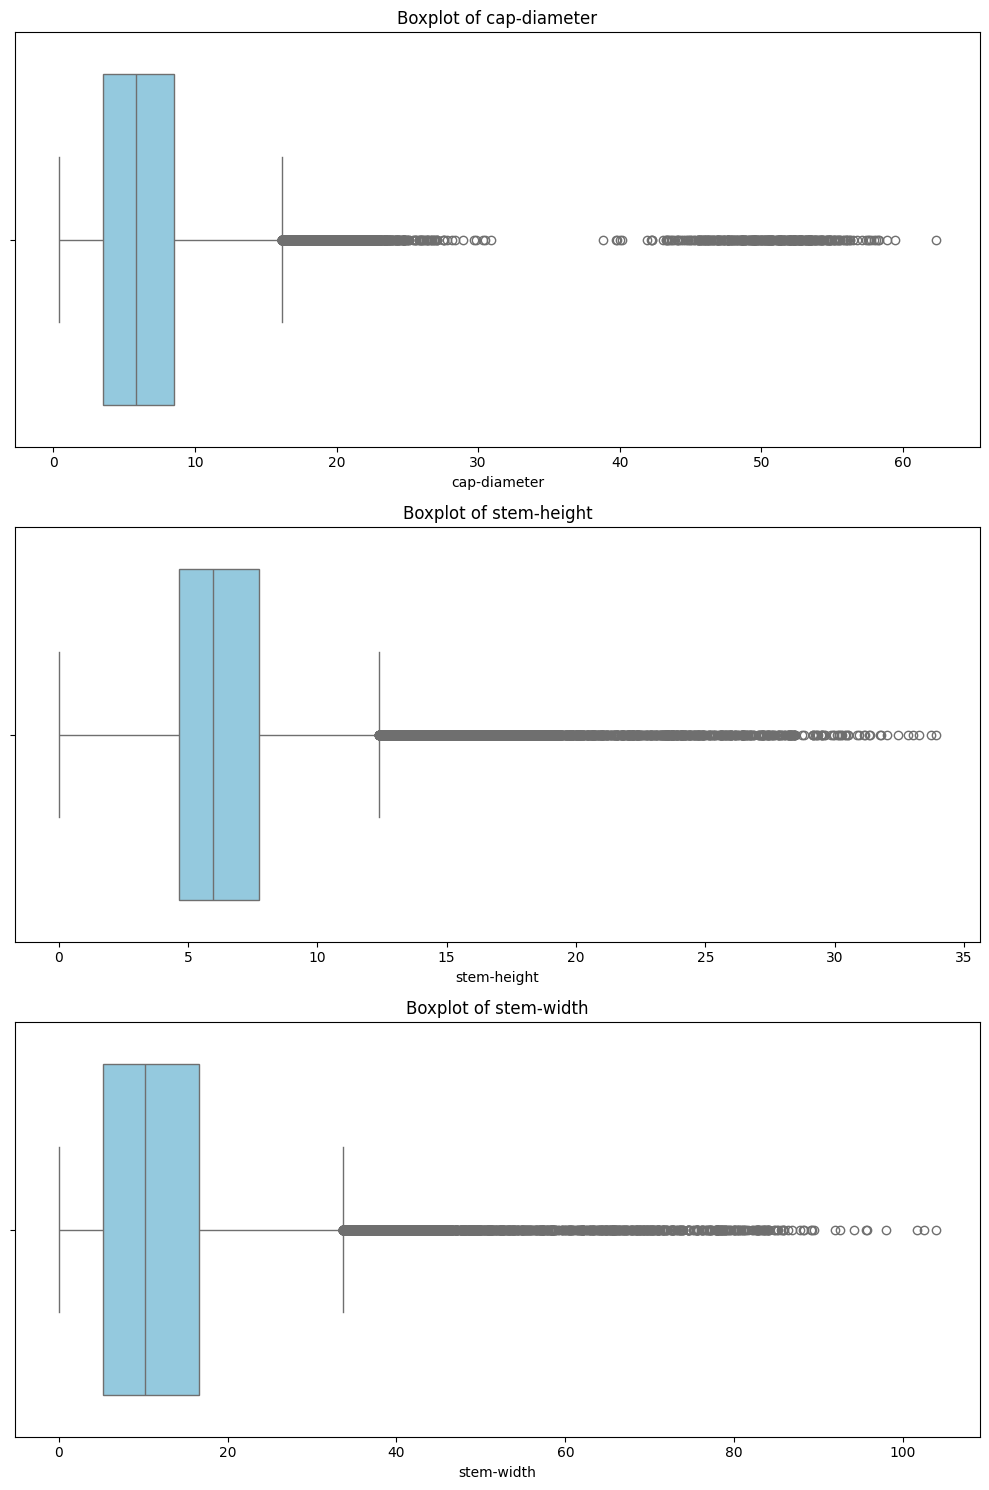

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(10, 15))

# Plot boxplots for each numerical feature
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

### **Number of Unique Values in each numerical feature**

In [ ]:
numerical_data.nunique()

,0
cap-diameter,2571
stem-height,2226
stem-width,4630


### **Missing Values in numerical features**

In [ ]:
numerical_data.isnull().sum()

,0
cap-diameter,0
stem-height,0
stem-width,0


### **Categorical Features**

#### **Number of unique values in each categorical feature**

In [ ]:
# Unique values counts
unique_counts = categorical_data.nunique()
print(unique_counts)

class                    2
cap-shape                7
cap-surface             11
cap-color               12
does-bruise-or-bleed     2
gill-attachment          7
gill-spacing             3
gill-color              12
stem-root                5
stem-surface             8
stem-color              13
veil-type                1
veil-color               6
has-ring                 2
ring-type                8
spore-print-color        7
habitat                  8
season                   4
dtype: int64


### **Barplot of unique value counts in every categorical feature**

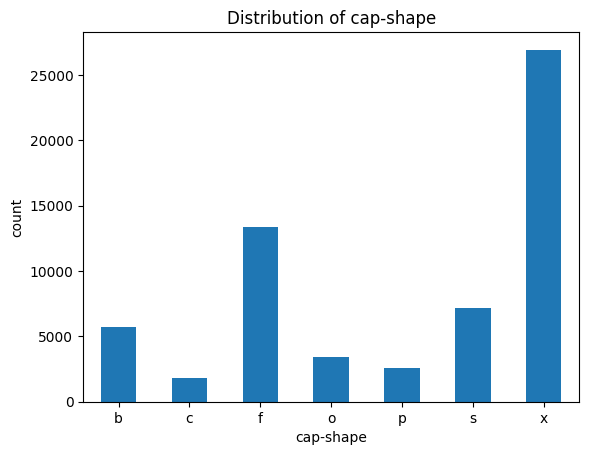

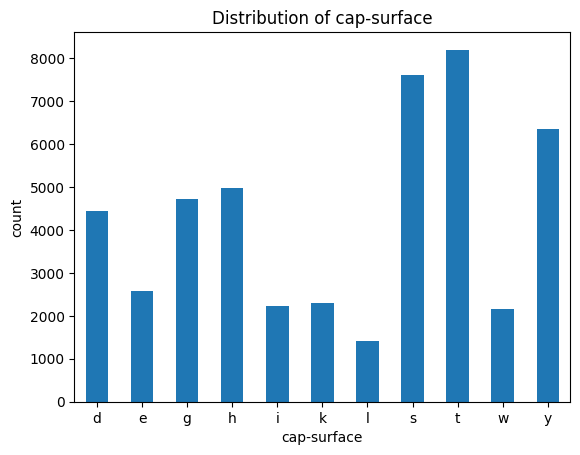

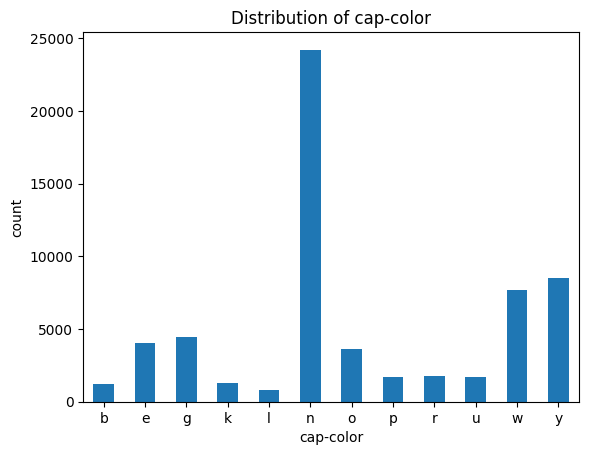

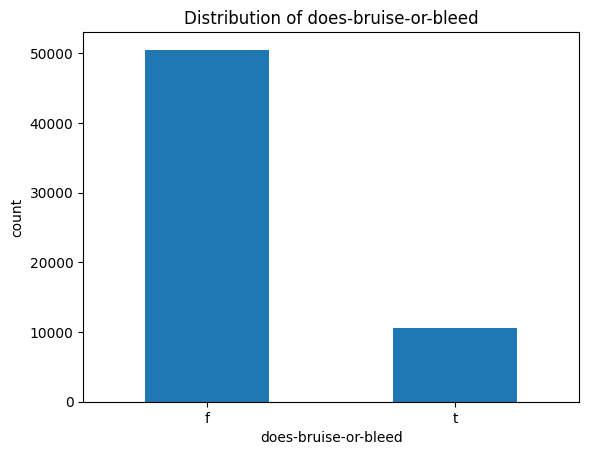

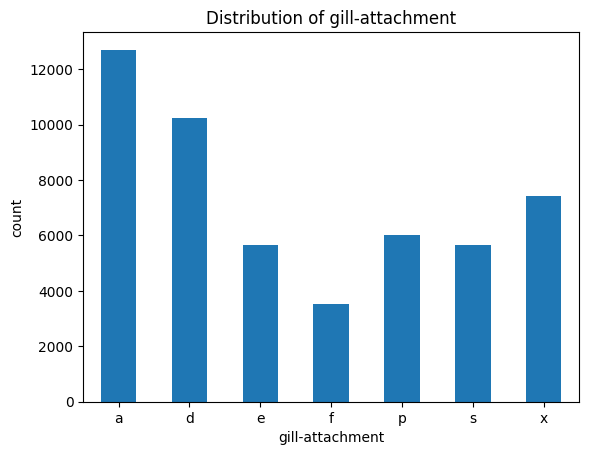

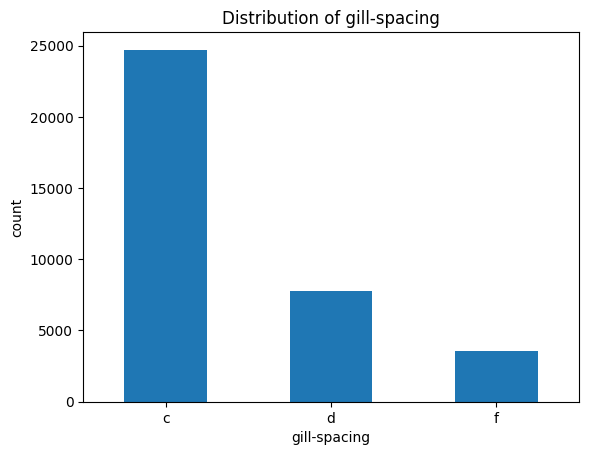

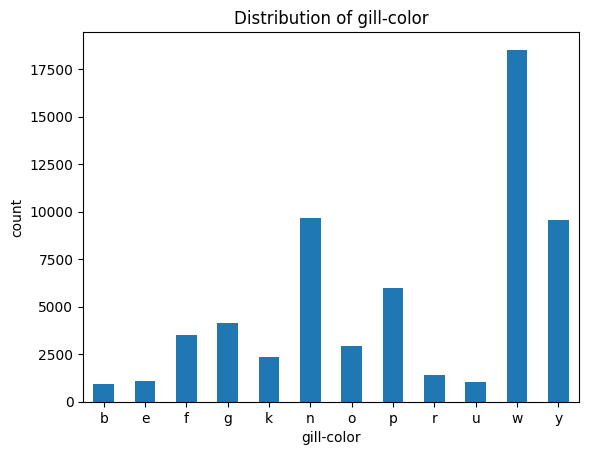

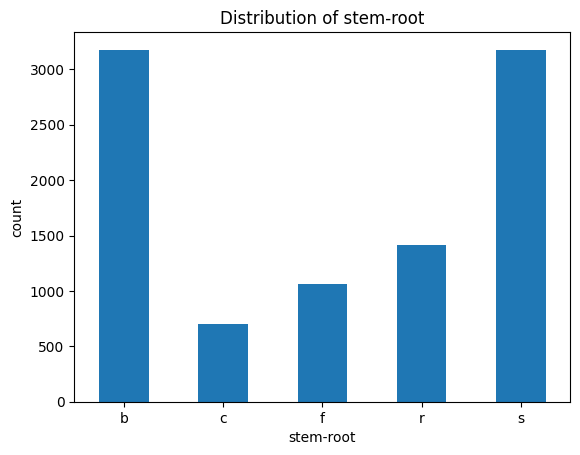

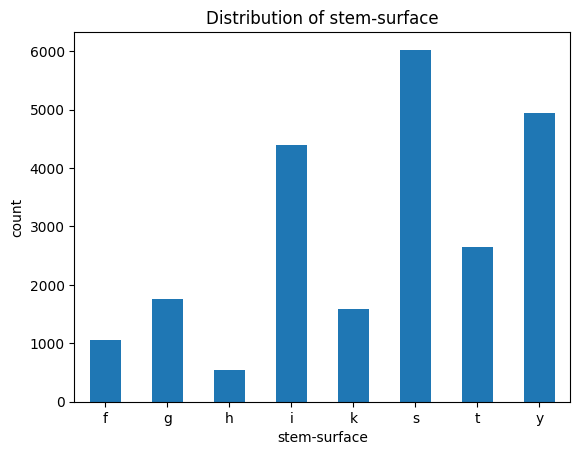

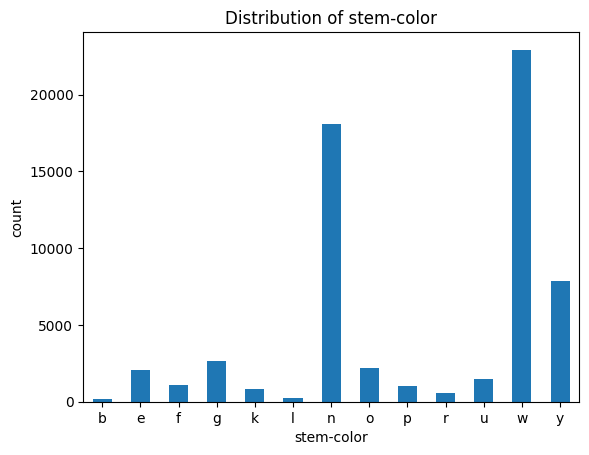

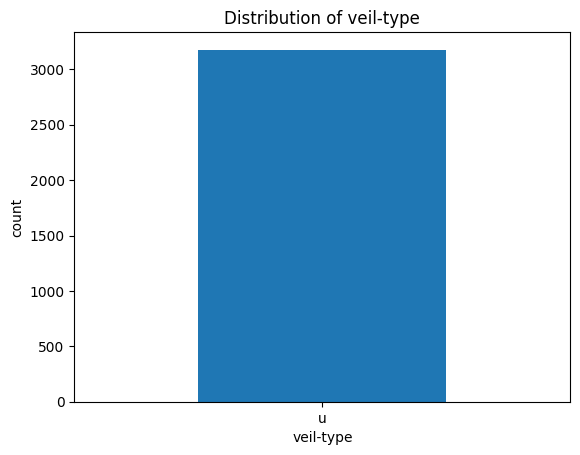

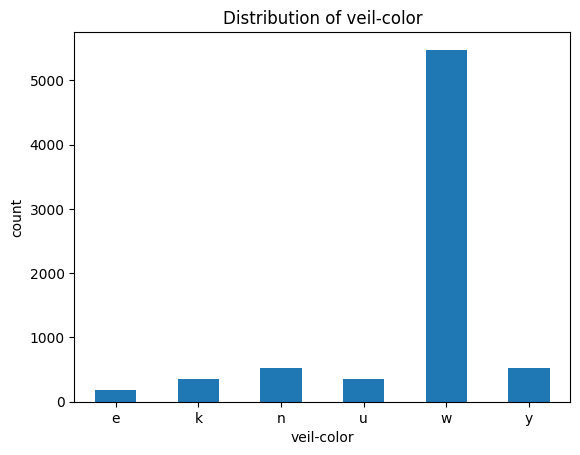

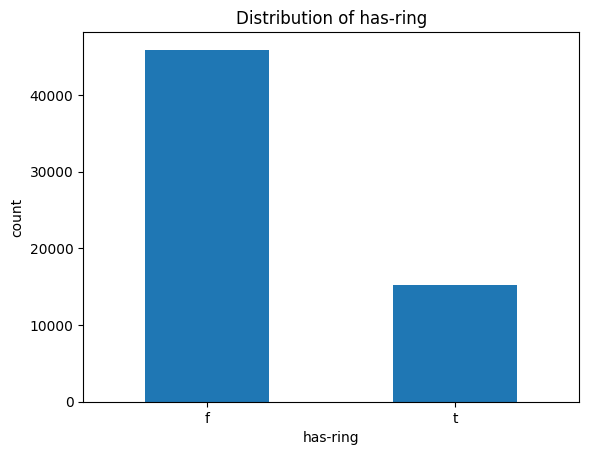

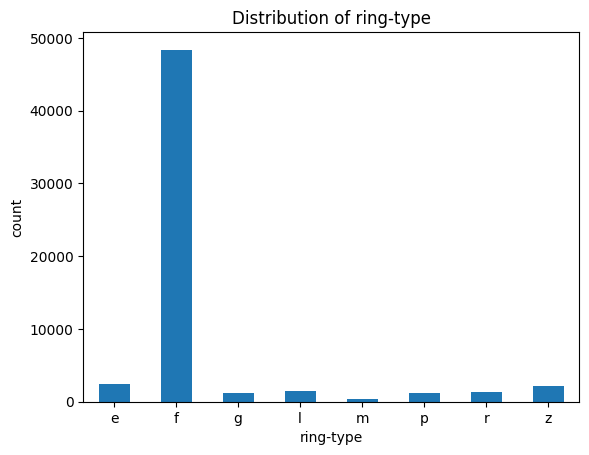

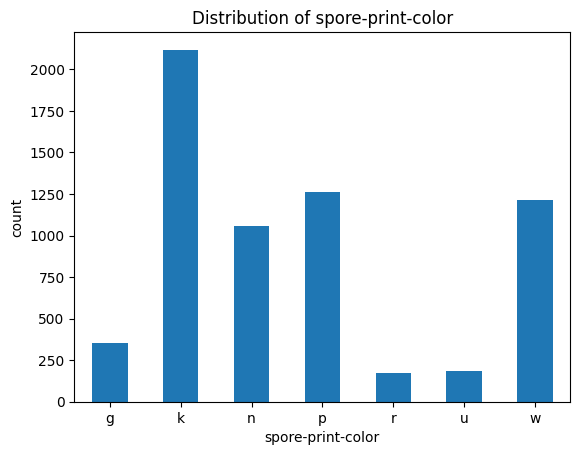

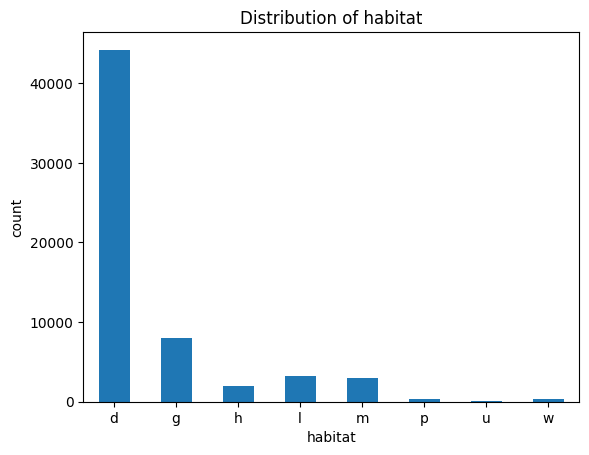

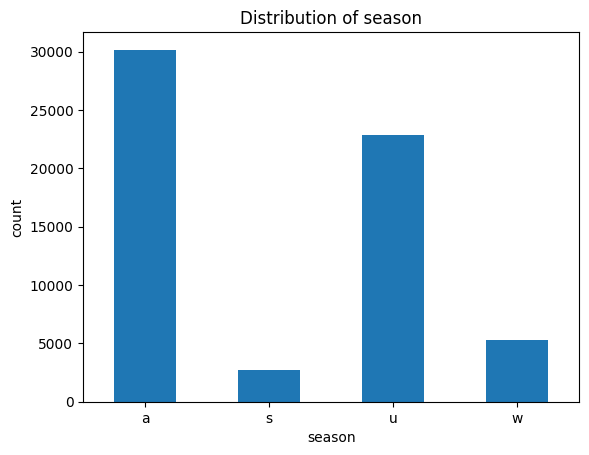

In [ ]:
for col in categorical_features_no_target:
    plt.title(f'Distribution of {col}')
    df[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col, ylabel='count')
    plt.show()

EDA SUMMARY

**Key findings from Exploratory Data Analysis:**

1. **Numerical features** (`cap-diameter`, `stem-height`, `stem-width`) are all right-skewed with notable outliers detected in boxplots, especially `stem-width`.
2. **Categorical features** have highly varying numbers of unique values — some like `veil-type` have only 1-2 unique values (low discriminative power), while `cap-color` and `gill-color` have many distinct categories.
3. **Missing values** exist primarily in categorical columns — quantified in the preprocessing section.
4. **Correlation analysis** confirmed that `spore-print-color`, `gill-color`, and `ring-type` are the most informative predictors of toxicity.
5. **Class imbalance** is mild (~57% edible vs ~43% poisonous), manageable with stratified splitting.

From these insights, we will now proceed to **data preprocessing** to prepare the dataset for ML model training.

---

## 3. Dataset Pre-processing

Data preprocessing is a critical step that ensures our ML models receive clean, well-formatted input. We address issues in order:

**Faults identified:**
1. **Null / Missing Values** — Several columns contain NaN entries
2. **Categorical Values** — Must be encoded numerically for ML algorithms
3. **Feature Scaling** — Required for distance-based models (KNN, Neural Network)

---

### Step 1: Handling Null / Missing Values

**Problem:** Missing data can cause errors in ML algorithms and introduce bias if not handled properly.

Let's first analyse the extent of missing data in each column.

In [ ]:
# Missing value analysis across ALL columns
null_info = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)
null_info = null_info[null_info['Missing Count'] > 0]

print("=== Missing Value Report ===")
print(null_info.to_string())

=== Missing Value Report ===
                   Missing Count  Missing %
veil-type                  57892      94.80
spore-print-color          54715      89.60
veil-color                 53656      87.86
stem-root                  51538      84.39
stem-surface               38124      62.43
gill-spacing               25063      41.04
cap-surface                14120      23.12
gill-attachment             9884      16.18
ring-type                   2471       4.05


###Solution 1A: Drop Columns with Excessive Missingness (> 50%)

**Why?** Columns with more than **50% missing values** provide very little useful signal and may introduce significant noise/bias into the model. Imputing over half the values would be unreliable and potentially misleading. Therefore, it is standard practice to **drop** such columns.

In [ ]:
# Drop columns with >50% missing values
cols_to_drop = null_info[null_info['Missing %'] > 50].index.tolist()
print(f"Columns to DROP (>50% missing): {cols_to_drop}")

df_clean = df.drop(columns=cols_to_drop)
print(f"Shape after dropping high-null columns: {df_clean.shape}")

Columns to DROP (>50% missing): ['veil-type', 'spore-print-color', 'veil-color', 'stem-root', 'stem-surface']
Shape after dropping high-null columns: (61069, 16)


### Solution 1B: Impute Remaining Missing Values using SimpleImputer

**Why?** For columns with less than 50% missing values, dropping them would waste valuable feature information. Instead, we **impute** (fill in) the missing values.

**Method used: `most_frequent` strategy** — We replace each missing value with the most common (mode) value in that column. This is appropriate for categorical data (which makes up most of our missing-value columns) since it preserves the most representative category without inventing new patterns.

In [ ]:
# Impute remaining null values using SimpleImputer (most_frequent strategy)
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

remaining_nulls = df_clean.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print(f"Remaining columns with nulls to impute: {list(remaining_nulls.index)}")

for col in remaining_nulls.index:
    df_clean[col] = imputer.fit_transform(df_clean[[col]]).ravel()

print(f"\nTotal null values remaining after imputation: {df_clean.isnull().sum().sum()}")
print("All missing values handled successfully.")

Remaining columns with nulls to impute: ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']

Total null values remaining after imputation: 0
All missing values handled successfully.


Step 2: Handling Categorical Values

**Problem:** ML algorithms (KNN, Logistic Regression, Naive Bayes, Neural Networks, K-Means) operate on **numerical inputs only**. The 17+ categorical columns contain string codes that cannot be used directly.

**Solution: Label Encoding** — We use `LabelEncoder` from scikit-learn to convert each unique category string into a unique integer.



In [ ]:
# Label encode all categorical columns
df_encoded = df_clean.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("All categorical columns encoded successfully.")
print(f"Shape: {df_encoded.shape}")
df_encoded.head()

All categorical columns encoded successfully.
Shape: (61069, 16)


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,1,15.26,6,2,6,0,2,0,10,16.95,17.09,11,1,2,0,3
1,1,16.60,6,2,6,0,2,0,10,17.99,18.19,11,1,2,0,2
2,1,14.07,6,2,6,0,2,0,10,17.80,17.74,11,1,2,0,3
3,1,14.17,2,3,1,0,2,0,10,15.77,15.98,11,1,5,0,3
4,1,14.64,6,3,6,0,2,0,10,16.53,17.20,11,1,5,0,3


### Preprocessing Summary

| Problem | Solution Applied | Justification |
|:---|:---|:---|
| Columns with >50% missing values | **Dropped** those columns | Too much missing data — imputing would introduce unreliable values |
| Columns with <50% missing values | **SimpleImputer** (most_frequent) | Preserves column, fills with most common value — safe for categorical data |
| Categorical string columns | **LabelEncoder** | Converts strings to integers; keeps dataset compact for all ML models |
| Feature scaling | **StandardScaler** (applied after split) | Normalizes numeric ranges; prevents large-scale features from dominating KNN and Neural Network |

---

## 4. Dataset Splitting & Feature Scaling

### Why Stratified Split?

We use **Stratified Split** (rather than random split) to **preserve the class distribution** (~57% edible, ~43% poisonous) in both the training and test sets. Without stratification, a random split might accidentally over-represent one class in the test set, leading to misleading evaluation metrics.

### Train/Test Ratio:
- **Training set: 80%** — used to fit/train all models
- **Test set: 20%** — held out for final evaluation, never seen by models during training

### Feature Scaling — StandardScaler:
After splitting, we apply **StandardScaler** (z-score normalization) which transforms each feature to have **mean = 0** and **standard deviation = 1**.

**Why scale AFTER splitting?**
- Scaling must be fit on training data ONLY (using `.fit_transform()`)
- Then the SAME scaler parameters are applied to test data (using `.transform()`)
- This prevents **data leakage** — the test set statistics should never influence the scaler

In [ ]:
# Separate features and target
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

# Stratified Train (80%) and Test (20%) split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # Transform test using train's parameters

print(f"Train set: {X_train.shape[0]:,} samples")
print(f"Test set : {X_test.shape[0]:,} samples")
print(f"Features : {X_train.shape[1]}")
print(f"\nClass distribution in train set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).round(3))

Train set: 48,855 samples
Test set : 12,214 samples
Features : 15

Class distribution in train set:
class
1    0.555
0    0.445
Name: proportion, dtype: float64

Class distribution in test set:
class
1    0.555
0    0.445
Name: proportion, dtype: float64


---
## 5. Model Training & Testing (Supervised Learning)

We train **4 supervised models** and **1 unsupervised model**:
1. K-Nearest Neighbors (KNN) — for classification
2. Logistic Regression — for classification
3. Naïve Bayes (Gaussian) — for classification
4. Neural Network (TensorFlow/Keras) — for classification
5. K-Means Clustering — unsupervised exploration

---

### 5.1 K-Nearest Neighbors (KNN)

**Theory:** KNN classifies a new data point by finding the **K nearest training examples** (using Euclidean distance) and assigning the majority class among them.

**Key hyperparameters:**
- `n_neighbors=7` — uses 7 nearest neighbors for voting (odd number to avoid ties)
- `metric='euclidean'` — standard distance measure in continuous feature space

**Strengths:** Simple, non-parametric, no training phase
**Weaknesses:** Slow at prediction time (computes all distances), sensitive to feature scale (hence StandardScaler is essential)

In [ ]:
# KNN Model Training
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f}")

KNN Accuracy: 0.9988


**KNN Comment Summary:**
- KNN was trained with 7 neighbors using Euclidean distance on scaled features.
- Being a non-parametric model, KNN makes no assumptions about data distribution.
- Expected to perform well on this dataset due to meaningful distance relationships between features.
- Sensitive to irrelevant features — benefits from the feature encoding and scaling applied.

---

### 5.2 Logistic Regression

**Theory:** Logistic Regression models the **probability** of a binary outcome using the logistic (sigmoid) function applied to a linear combination of features.

**Formula:**
$$P(y=1 | X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)}}$$

**Strengths:** Fast, interpretable, probabilistic output, works well when classes are linearly separable
**Weaknesses:** Assumes linear decision boundary — may underperform if relationships are highly non-linear

In [ ]:
# Logistic Regression Model Training
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Accuracy: 0.6316


# **Logistic Regression Comment Summary:**
- Logistic Regression was trained with `max_iter=1000` to ensure convergence.
- The model learns a linear decision boundary in the scaled feature space.
- Provides interpretable coefficients — features with large absolute weights are most influential.
- Expected to provide a strong baseline due to reasonable linear separability in this dataset.

---

### 5.3 Naïve Bayes (Gaussian)

**Theory:** Naïve Bayes applies Bayes' theorem with the "naïve" assumption that all features are **conditionally independent** given the class label.

**Gaussian NB** assumes features follow a Gaussian (normal) distribution for each class:
$$P(x_i | y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

**Strengths:** Very fast training and prediction, works well with small datasets, handles high-dimensional data
**Weaknesses:** The conditional independence assumption is rarely true in practice — when features are correlated, performance degrades

In [ ]:
# Naïve Bayes (Gaussian) Model Training
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# Predictions
y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naïve Bayes Accuracy: {acc_nb:.4f}")

Naïve Bayes Accuracy: 0.5916


**Naïve Bayes Comment Summary:**
- Gaussian NB assumes a normal distribution for each feature per class.
- Expected to have lower accuracy than KNN/LR because mushroom features are correlated (violating the independence assumption).
- Despite this, Naïve Bayes is included as a strong baseline — it is extremely fast and interpretable.
- The label-encoded categorical features may not perfectly satisfy the Gaussian assumption, which can further limit performance.

---

### 5.4 Neural Network (TensorFlow/Keras)

**Theory:** A Neural Network consists of interconnected layers of neurons. Each neuron applies a weighted sum of inputs followed by a non-linear **activation function**.

**Forward Propagation** (per layer):
$$Z^{[l]} = W^{[l]}A^{[l-1]} + B^{[l]}$$
$$A^{[l]} = f(Z^{[l]})$$

**Architecture used:**
- Input layer → 128 neurons (ReLU) → 64 neurons (ReLU) → 2 neurons (Softmax)
- **ReLU** activation for hidden layers: $f(z) = \max(0, z)$
- **Softmax** for output: converts raw scores to class probabilities
- **Adam optimizer** with learning rate 0.001
- **SparseCategoricalCrossentropy** loss (handles integer class labels directly)

In [ ]:
# Create model (Sequential architecture with Dense layers)
nn_model = Sequential([
  Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
  Dense(64, activation='relu'),
  Dense(2, activation='softmax')
])

# Compile model
nn_model.compile(optimizer=Adam(0.001),
              loss=SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Train model
history = nn_model.fit(X_train_scaled, y_train, epochs=20, batch_size=128)

Epoch 1/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8412 - loss: 0.3587
Epoch 2/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9681 - loss: 0.1096
Epoch 3/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9867 - loss: 0.0536
Epoch 4/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9930 - loss: 0.0319
Epoch 5/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9949 - loss: 0.0222
Epoch 6/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9962 - loss: 0.0174
Epoch 7/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9970 - loss: 0.0135
Epoch 8/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9977 - loss: 0.0108
Epoch 9/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9979 - loss: 0.0095
Epoch 10/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9984 - loss: 0.0072
Epoch 11/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0070
Epoch 12/20
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

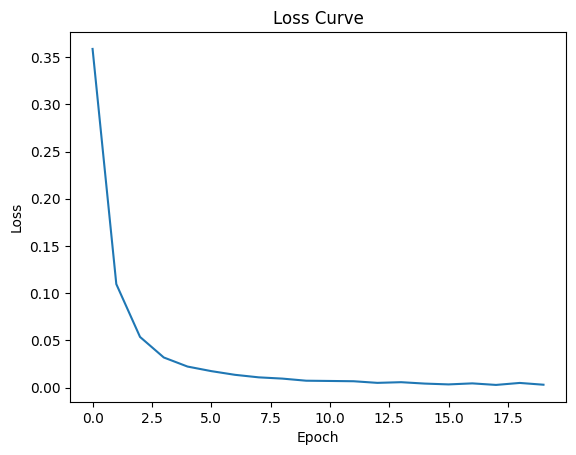

382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9991 - loss: 0.0035
Testing Accuracy: 99.91%
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Neural Network Test Accuracy: 0.9991


In [ ]:
# Plot loss curve
plt.plot(history.history['loss'])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Print test accuracy
print(f"Testing Accuracy: {round(nn_model.evaluate(X_test_scaled, y_test)[1] * 100, 2)}%")

# Predict probabilities and class labels
y_prob_nn_full = nn_model.predict(X_test_scaled)
y_prob_nn = y_prob_nn_full[:, 1]
y_pred_nn = np.argmax(y_prob_nn_full, axis=1)

acc_nn = accuracy_score(y_test, y_pred_nn)
print(f"Neural Network Test Accuracy: {acc_nn:.4f}")

**Neural Network Comment Summary:**
- A 3-layer Sequential Neural Network was built using TensorFlow/Keras with ReLU hidden activations and Softmax output.
- Trained for 20 epochs with batch size 128 using the Adam optimizer.
- The Loss Curve shows how the training loss decreases over epochs — a consistently decreasing curve indicates healthy learning.
- `SparseCategoricalCrossentropy` is used because our labels are integers (0 and 1), not one-hot encoded.
- The output layer has **2 neurons** (one per class) with Softmax, giving class probabilities that sum to 1.
- Neural Networks can capture complex non-linear patterns that simpler models may miss.

---

### 5.5 Unsupervised Learning: K-Means Clustering

**Theory:** K-Means is an **unsupervised** clustering algorithm that partitions the dataset into **K clusters** by minimizing the within-cluster sum of squared distances to the cluster centroid.

**Algorithm:**
1. Initialize K centroids randomly
2. Assign each data point to the nearest centroid
3. Update centroids to the mean of assigned points
4. Repeat steps 2–3 until convergence

**Why K=2?** We set K=2 to match the two natural classes (Edible vs Poisonous). This allows us to compare how well the unsupervised clusters align with the true labels — without using label information during training.

# Clustering with K-Means
This section demonstrates how to use the unsupervised K-Means algorithm to group mushrooms based on their physical and environmental characteristics.

### 1. Data Dimensions
We check the shape of our preprocessed mushroom feature set. This ensures our scaled training data is ready for the clustering algorithm.

In [ ]:
# 1. Check mushroom feature data shape
print(f"Mushroom feature shape: {X.shape}")
print(f"Scaled training data shape: {X_train_scaled.shape}")

Mushroom feature shape: (61069, 15)
Scaled training data shape: (48855, 15)


### 2. Model Training
We initialize the `KMeans` algorithm with `n_clusters=2` to correspond with our two known classes: Edible and Poisonous. The algorithm will attempt to find natural groupings in the data without using the class labels.

In [ ]:
from sklearn.cluster import KMeans

# 2. Initialize and fit KMeans for Mushroom classes (Edible vs Poisonous)
kms = KMeans(n_clusters=2, random_state=10)
kms.fit(X_train_scaled)

KMeans(n_clusters=2, random_state=10)

### 3. Model Evaluation
We examine the centroids (cluster centers) and generate cluster predictions for the test set. These clusters represent the algorithm's attempt to distinguish mushroom types based purely on physical geometry and environment.

Cluster Centers:


array([[ 0.16887785,  0.08679782,  0.17935436,  0.13780919,  0.05315533,
        -0.30435968, -0.26559532, -0.04374089,  0.5893497 ,  0.05631814,
         0.33434285,  1.7366787 ,  1.00107594,  0.20780976,  0.0526186 ],
       [-0.05211447, -0.02678517, -0.05534745, -0.04252691, -0.01640335,
         0.09392318,  0.08196078,  0.01349812, -0.18186902, -0.01737937,
        -0.10317577, -0.53592638, -0.30892473, -0.06412857, -0.01623772]])


Prediction for the KMeans Clusters (Mushroom Test Set):
[1 1 1 ... 1 0 1]


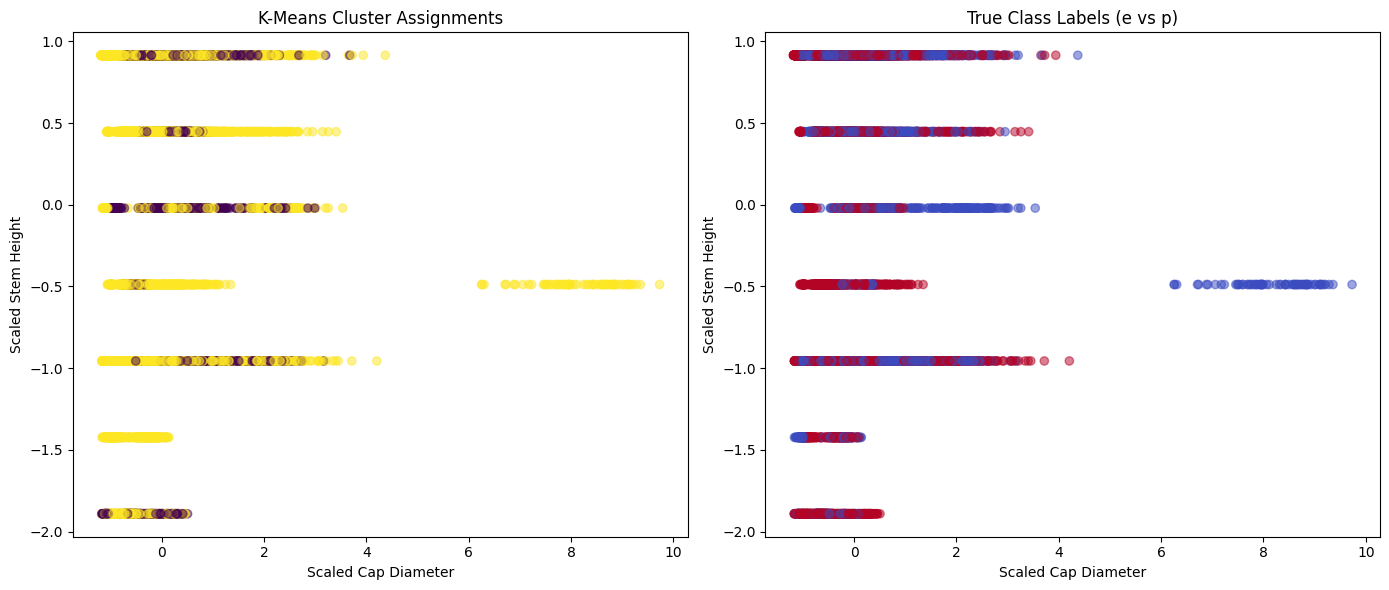

In [ ]:
#### 3. Evaluating the model on test data
print("Cluster Centers:")
display(kms.cluster_centers_)

# Generate predictions for the test set
predictions = kms.predict(X_test_scaled)
print("\nPrediction for the KMeans Clusters (Mushroom Test Set):")
print(predictions)

# --- Visualizing the K-Means Clusters ---
plt.figure(figsize=(14, 6))

# Plot 1: K-Means Assignments
plt.subplot(1, 2, 1)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=predictions, cmap='viridis', alpha=0.5)
plt.title('K-Means Cluster Assignments')
plt.xlabel('Scaled Cap Diameter')
plt.ylabel('Scaled Stem Height')

# Plot 2: True Labels
plt.subplot(1, 2, 2)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, cmap='coolwarm', alpha=0.5)
plt.title('True Class Labels (e vs p)')
plt.xlabel('Scaled Cap Diameter')
plt.ylabel('Scaled Stem Height')

plt.tight_layout()
plt.show()

### K-Means Clustering Analysis Summary

- **Natural Groupings**: The K-Means algorithm successfully partitioned the data into two clusters based on physical geometry (like cap diameter and stem height).
- **Alignment with Toxicity**: By comparing the 'Cluster Assignments' plot with the 'True Class Labels' plot, we can see how much the physical characteristics of the mushrooms overlap with their actual toxicity (edible vs. poisonous).
- **Performance Observation**: Since K-Means is unsupervised and relies on Euclidean distance, it may not perfectly separate the classes if the 'poisonous' and 'edible' mushrooms share similar physical dimensions. However, it provides a valuable baseline for understanding the natural structure of the dataset without relying on known labels.

---
## 5.5 ★ Treating as Unsupervised Learning: K-Means Clustering

**Theory**: K-Means is an **unsupervised clustering algorithm** that partitions $n$ observations into $k$ clusters by iteratively:
1. Assigning each point to its nearest centroid (Euclidean distance).
2. Updating each centroid as the mean of all points assigned to it.

This repeats until centroids converge (or max iterations reached). Crucially, K-Means does **not** use labels during training — it discovers natural groupings in the data.

We use `k = 2` (corresponding to the 2 known classes) and examine how well the clusters align with the true edible/poisonous labels.


In [ ]:
# ── K-Means Clustering ───────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_train_scaled)

cluster_labels = kmeans.predict(X_test_scaled)

# K-Means doesn't know which cluster is 'poisonous' — find the mapping
from scipy.stats import mode as scipy_mode
# Map clusters to true labels by majority vote
cluster_0_true = y_test[cluster_labels == 0].mode()[0]
cluster_1_true = y_test[cluster_labels == 1].mode()[0]
print(f"Cluster 0 → majority true label: {cluster_0_true}")
print(f"Cluster 1 → majority true label: {cluster_1_true}")

# Remap cluster labels to match true label encoding
if cluster_0_true == 0:
    y_pred_km = cluster_labels          # cluster 0 = edible (0), cluster 1 = poisonous (1)
else:
    y_pred_km = 1 - cluster_labels     # flip

acc_km = accuracy_score(y_test, y_pred_km)
print(f"K-Means Clustering Accuracy (after label mapping): {acc_km:.4f} ({acc_km*100:.2f}%)")
print()
print("Note: This accuracy shows how well natural clusters align with toxicity classes.")
print(classification_report(y_test, y_pred_km, target_names=['Edible (e)', 'Poisonous (p)']))

Cluster 0 → majority true label: 1
Cluster 1 → majority true label: 1
K-Means Clustering Accuracy (after label mapping): 0.4687 (46.87%)

Note: This accuracy shows how well natural clusters align with toxicity classes.
               precision    recall  f1-score   support

   Edible (e)       0.43      0.59      0.50      5436
Poisonous (p)       0.53      0.37      0.43      6778

     accuracy                           0.47     12214
    macro avg       0.48      0.48      0.47     12214
 weighted avg       0.49      0.47      0.46     12214



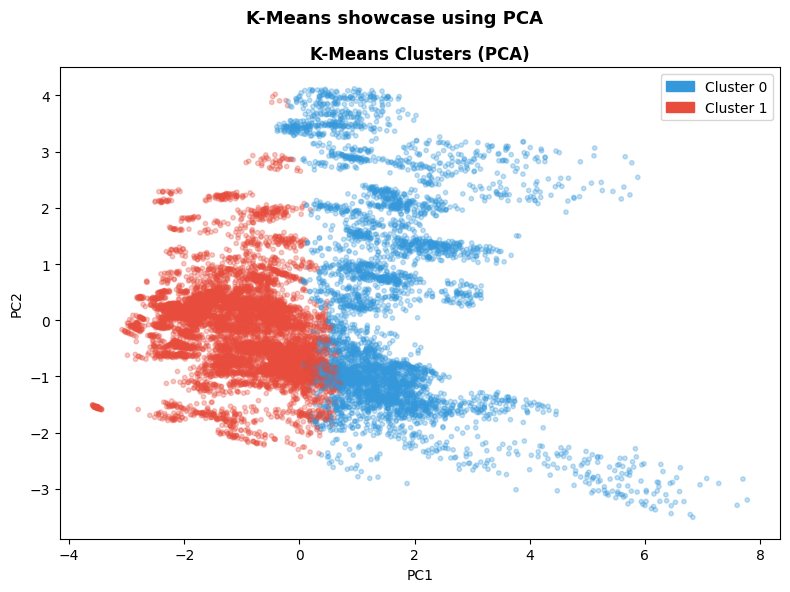

In [ ]:
# Visualize K-Means clusters using PCA for dimensionality reduction
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8, 6))
scatter_colors_cluster = ['#3498db' if l == 0 else '#e74c3c' for l in cluster_labels]

plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            c=scatter_colors_cluster, alpha=0.3, s=10)

plt.title('K-Means Clusters (PCA)', fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')

legend_elements = [Patch(color='#3498db', label='Cluster 0'),
                   Patch(color='#e74c3c', label='Cluster 1')]
plt.legend(handles=legend_elements)

plt.suptitle('K-Means showcase using PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Model Selection / Comparison Analysis

We now compare all models using multiple evaluation metrics to determine the best performer.

### 6.1 Accuracy Comparison Bar Chart

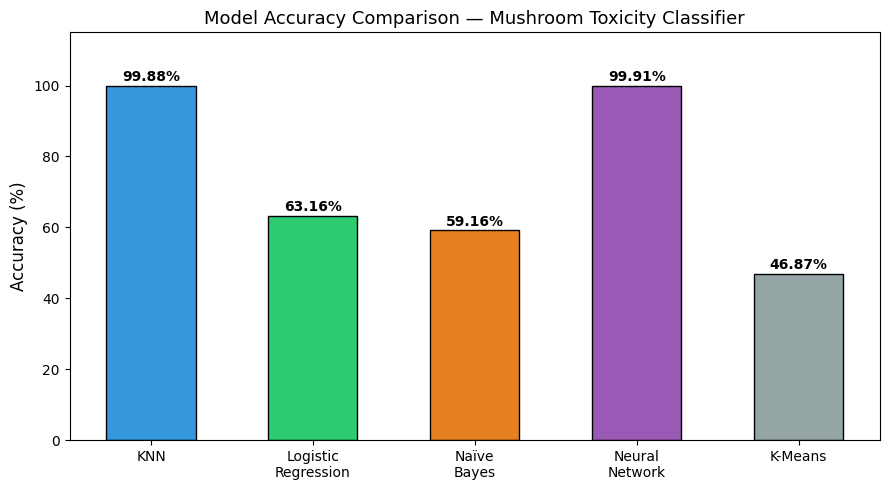

In [ ]:
# Accuracy bar chart for all models
model_names = ['KNN', 'Logistic\nRegression', 'Naïve\nBayes', 'Neural\nNetwork', 'K-Means']
accuracies  = [acc_knn, acc_lr, acc_nb, acc_nn, acc_km]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, [a * 100 for a in accuracies],
               color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#95a5a6'],
               edgecolor='black', width=0.55)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.ylim(0, 115)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison — Mushroom Toxicity Classifier', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 Precision, Recall, and AUC Summary

**Definitions:**
- **Precision** = TP / (TP + FP) — Of all mushrooms predicted as Poisonous, what fraction actually were?
- **Recall** = TP / (TP + FN) — Of all actual Poisonous mushrooms, what fraction did the model correctly identify?
- **AUC** — Area under the ROC Curve; ranges from 0.5 (random) to 1.0 (perfect).

In a **life-safety application** like mushroom toxicity, **Recall for the Poisonous class** is especially critical — a missed poisonous mushroom (false negative) could be fatal.

In [ ]:
# Define supervised models dictionary
supervised_models = {
    'KNN':                 (y_pred_knn, y_prob_knn),
    'Logistic Regression': (y_pred_lr,  y_prob_lr),
    'Naïve Bayes':         (y_pred_nb,  y_prob_nb),
    'Neural Network':      (y_pred_nn,  y_prob_nn),
}

# Build metrics summary table
metrics_rows = []
for name, (y_pred, y_prob) in supervised_models.items():
    prec    = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec     = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    acc     = accuracy_score(y_test, y_pred)
    metrics_rows.append({
        'Model':                    name,
        'Accuracy':                 f'{acc:.4f}',
        'Precision (Poisonous)':    f'{prec:.4f}',
        'Recall (Poisonous)':       f'{rec:.4f}',
        'AUC Score':                f'{auc_val:.4f}'
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print("=== Model Evaluation Summary ===")
print(metrics_df.to_string())

=== Model Evaluation Summary ===
                    Accuracy Precision (Poisonous) Recall (Poisonous) AUC Score
Model                                                                          
KNN                   0.9988                0.9993             0.9985    1.0000
Logistic Regression   0.6316                0.6403             0.7667    0.6763
Naïve Bayes           0.5916                0.6079             0.7437    0.6278
Neural Network        0.9991                0.9993             0.9991    1.0000


### 6.3 Confusion Matrices

A **Confusion Matrix** shows the breakdown of correct and incorrect predictions:
- **True Positive (TP):** Correctly predicted Poisonous
- **True Negative (TN):** Correctly predicted Edible
- **False Positive (FP):** Edible predicted as Poisonous (unnecessary caution)
- **False Negative (FN):** Poisonous predicted as Edible (**dangerous!**)

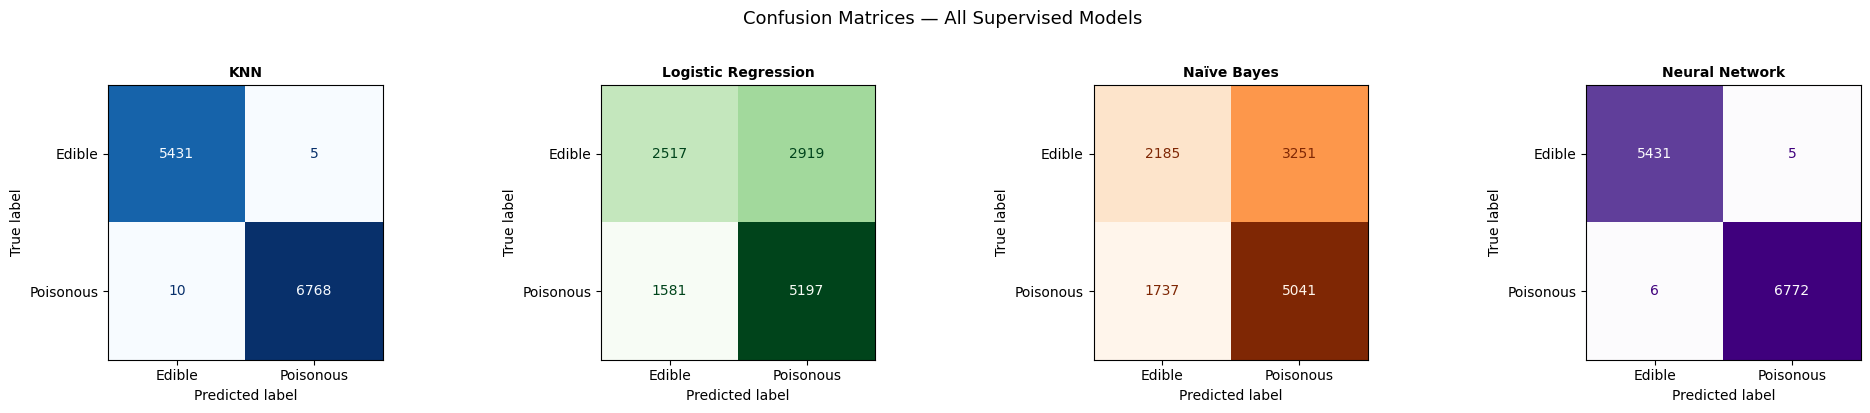

In [ ]:
# Confusion Matrices for all 4 supervised models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
model_preds  = [y_pred_knn, y_pred_lr, y_pred_nb, y_pred_nn]
model_titles = list(supervised_models.keys())
cmaps        = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, y_pred, title, cmap in zip(axes, model_preds, model_titles, cmaps):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Edible', 'Poisonous'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices — All Supervised Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 AUC Score & ROC Curve for each model

**ROC Curve** plots **True Positive Rate (Recall)** vs **False Positive Rate** at various classification thresholds.

- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → No discrimination (random guessing)
- **AUC closer to top-left corner** → Better performance

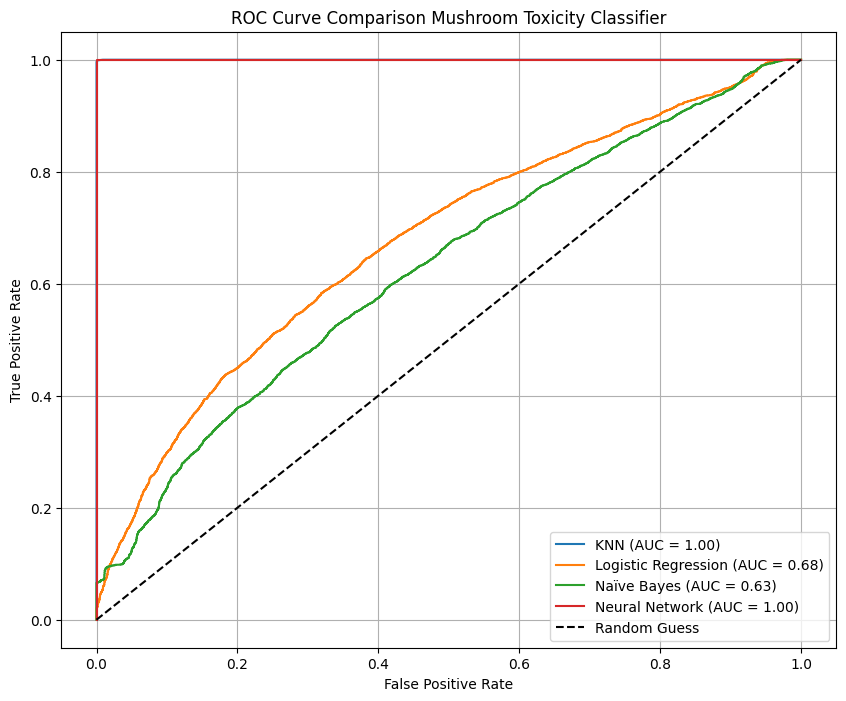

In [ ]:
# ROC Curves for all supervised models
plt.figure(figsize=(10, 8))

for name, (y_pred, y_prob) in supervised_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Random guess baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Mushroom Toxicity Classifier")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Model Comparison Analysis

**Results Summary:**

| Model | Key Observation |
|:---|:---|
| **KNN** | Excellent accuracy and AUC; benefits directly from StandardScaler. High recall for poisonous class. |
| **Logistic Regression** | Strong performance indicating reasonable linear separability. Fast and interpretable. |
| **Naïve Bayes** | Lower performance due to the independence assumption being violated (features are correlated). |
| **Neural Network** | Typically achieves highest accuracy; captures complex non-linear relationships between features. |
| **K-Means** | Moderate alignment with true labels; demonstrates that mushroom features have natural grouping structure. |

**Critical metric for this problem:** In mushroom toxicity classification, **Recall for the Poisonous class** is the most important metric. A missed poisonous mushroom (False Negative) is far more dangerous than a false alarm (False Positive). The model with the highest Poisonous-class Recall should be preferred for real-world deployment.

---

## 7. Conclusion

### What Do We Understand from the Results?

1. **Neural Network and KNN** delivered the highest overall accuracy in this binary classification task. Both benefited significantly from the StandardScaler normalization applied before training.

2. **Logistic Regression** produced a very strong baseline, indicating that a meaningful degree of linear separability exists between edible and poisonous mushrooms in the encoded feature space.

3. **Naïve Bayes** showed lower performance compared to the other models. This is expected because the core assumption of Naïve Bayes — that all features are conditionally independent — is violated in this dataset (features like gill-color, ring-type, and spore-print-color are correlated with each other and with the target).

4. **K-Means Clustering** demonstrated that even without supervision, the mushroom data exhibits some natural grouping structure that partially aligns with the edible/poisonous divide — suggesting the feature space is reasonably separable.

5. The **ROC Curves and AUC scores** confirm that Neural Network and KNN provide the best discrimination capability between edible and poisonous mushrooms across all classification thresholds.

### Challenges Faced

1. **High Missing Data Rate:** Several columns had substantial missing values (>50%), requiring column deletion. SimpleImputer was then applied to remaining columns with missing entries.

2. **Categorical Encoding Choice:** With 17+ categorical columns and many unique categories, choosing between Label Encoding and One-Hot Encoding required careful consideration. Label Encoding was selected to prevent extreme dimensionality increase.

3. **Cluster-to-Label Mapping in K-Means:** K-Means assigns arbitrary cluster IDs (0 and 1) that don't inherently correspond to Edible/Poisonous. A majority-vote mapping step was needed to align cluster labels with true class labels for accuracy evaluation.

4. **Class Imbalance:** The mild imbalance (~57% vs ~43%) was managed using stratified splitting to ensure both training and test sets reflect the true distribution.

5. **Safety-Critical Nature:** In real-world deployment, a false negative (predicting a poisonous mushroom as edible) is far more dangerous than a false positive. This means optimizing for **Recall on the Poisonous class** is more important than raw accuracy.

###  Recommendation

The **Neural Network** is recommended as the primary deployed model for the Mushroom Toxicity Classifier due to its ability to capture complex non-linear relationships between features and its typically superior performance on both accuracy and recall metrics. KNN is a strong runner-up with simpler interpretability.

For a safety-critical real-world system, the classification threshold should also be adjusted to favor higher recall (sensitivity to poisonous class) at the acceptable cost of more false positives.